In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from astropy.coordinates import get_sun
from astropy.time import Time

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)

def _ha_fmt(deg, pos=None):
    """Format decimal degrees as LaTeX $±HH^h MM^m$ (hour angle, no seconds)."""
    sign = '-' if deg < 0 else '+'
    h_abs = abs(deg) / 15.0
    hh = int(h_abs)
    mm = round((h_abs - hh) * 60)
    if mm == 60:
        hh += 1; mm = 0
    return rf'${sign}{hh}^h\,{mm:02d}^m$'

HA_FMT = mticker.FuncFormatter(_ha_fmt)

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
PLOT_BAND_GHZ = (9.9, 10.0)

DATA_DIRS = [
    Path('../../data/lab03/archive/sun_calibration_1'),   # Session 1: 15:04–15:21 UTC
    Path('../../data/lab03/archive/sun_calibration_2'),   # Session 2: 16:01–16:27 UTC
]
SESSION_LABELS = [
    'Session 1  (15:04 UTC,  alt 42--44 deg)',
    'Session 2  (16:01 UTC,  alt 31--36 deg)',
]
SESSION_COLORS = ['C0', 'C1']

paths_all  = [sorted(d.glob('*.npz')) for d in DATA_DIRS]
files_all  = [[np.load(p) for p in ps] for ps in paths_all]

f0        = files_all[0][0]
F_S_HZ    = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ  = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH      = int(f0['corr'].shape[0])
N_FFT     = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ     = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

for i, (d, fs) in enumerate(zip(DATA_DIRS, files_all)):
    print(f'Session {i+1}: {len(fs)} captures  |  {d.name}')
print(f'Freq axis: {F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  {DF_HZ/1e3:.1f} kHz/ch')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

amp_per_session = []
for fs in files_all:
    a = np.array([np.abs(f['corr']) for f in fs]).astype(float)
    a[:, BAD_CHANNELS] = np.nan
    amp_per_session.append(a)

# ── Normalise (global across both sessions) ───────────────────────────────
all_amp  = np.concatenate(amp_per_session, axis=0)
AMP_PEAK = np.nanmax(all_amp)
print(f'Global peak: {AMP_PEAK:.4f}  (max across both sessions)')

# Peak channel within PLOT_BAND_GHZ
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]
print(f'Peak channel: k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')

# # ── Plot: per-session spectra grids ───────────────────────────────────────
# NCOLS = 4
# for fs, label, color in zip(files_all, SESSION_LABELS, SESSION_COLORS):
#     n     = len(fs)
#     nrows = int(np.ceil(n / NCOLS))
#     fig, axes = plt.subplots(nrows, NCOLS, figsize=(TEXTWIDTH_IN, 2.2 * nrows))
#     axes_flat = np.array(axes).flatten()
#     for i, f in enumerate(fs):
#         ax  = axes_flat[i]
#         amp = np.abs(f['corr']).astype(float) / AMP_PEAK
#         amp[BAD_CHANNELS] = np.nan
#         ax.plot(F_SKY_GHZ, amp, lw=LW_FINE, color=color)
#         ax.set_title(
#             rf'\textrm{{cap\,{i:03d}}}' + '\n' +
#             rf'$\mathrm{{Alt}}={float(f["alt_deg"]):.1f}^{{\circ}}$',
#         )
#         if i % NCOLS == 0:
#             ax.set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
#         if i >= (nrows - 1) * NCOLS:
#             ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
#             ax.tick_params(axis='x', rotation=30)
#         ax.set_xlim(*PLOT_BAND_GHZ)
#         ax.set_ylim(0, 1.05)
#     for ax in axes_flat[n:]:
#         ax.set_visible(False)
#     fig.suptitle(
#         rf'Sun {label} --- spectra '
#         rf'({n}\,captures, $\Delta f={DF_HZ/1e3:.1f}$\,kHz)',
#     )
#     fig.tight_layout()
#     plt.show()

Session 1: 115 captures  |  sun_calibration_1
Session 2: 180 captures  |  sun_calibration_2
Freq axis: 9.7900 -- 10.0398 GHz  |  244.1 kHz/ch
Global peak: 0.6158  (max across both sessions)
Peak channel: k=577,  f_sky=9.9309 GHz


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_93376/194503983.py:46: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


In [3]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Sun's RA changes ~1°/day, so it must be recomputed per capture.
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _mid_unix(f):
    """Midpoint unix timestamp; falls back to legacy 'unix_time' key."""
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    """Sun's J2000 RA in degrees at the given unix time."""
    return get_sun(Time(unix_t, format='unix')).ra.deg

# Build per-session sorted data dict
sessions_data = []
for s_idx, (fs, ps, label) in enumerate(zip(files_all, paths_all, SESSION_LABELS)):
    unix_mid  = np.array([_mid_unix(f) for f in fs])
    order     = np.argsort(unix_mid)
    unix_sort = unix_mid[order]
    fs_s      = [fs[j] for j in order]
    ps_s      = [ps[j] for j in order]

    lst_arr    = np.array([_lst_deg(t) for t in unix_sort])
    sun_ra_arr = np.array([_sun_ra_deg(t) for t in unix_sort])
    ha_deg     = (lst_arr - sun_ra_arr) % 360.0
    ha_deg[ha_deg > 180.0] -= 360.0

    vis_peak  = np.array([f['corr'][k_peak] for f in fs_s])
    amp_peak  = np.abs(vis_peak) / AMP_PEAK
    phase_peak = np.rad2deg(np.angle(vis_peak))

    sessions_data.append(dict(
        files_s    = fs_s,
        paths_s    = ps_s,
        unix_sort  = unix_sort,
        ha_deg     = ha_deg,
        sun_ra_arr = sun_ra_arr,
        vis_peak   = vis_peak,
        amp_peak   = amp_peak,
        phase_peak = phase_peak,
    ))

    print(f'Session {s_idx+1} ({label}):')
    print(f'  Sun RA : {sun_ra_arr.min():.4f} -- {sun_ra_arr.max():.4f} deg  '
          f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f} deg)')
    print(f'  HA     : {ha_deg.min():.2f} -> {ha_deg.max():.2f} deg  '
          f'(span {ha_deg.max()-ha_deg.min():.2f} deg)')
    print(f'  Amp    : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
    print(f'  Phase  : mean={phase_peak.mean():.1f} deg,  std={phase_peak.std():.1f} deg')
    print()

Session 1 (Session 1  (15:04 UTC,  alt 42--44 deg)):
  Sun RA : 357.2021 -- 357.2126 deg  (span 0.0105 deg)
  HA     : 27.19 -> 31.34 deg  (span 4.15 deg)
  Amp    : mean=0.879,  std=0.032
  Phase  : mean=90.8 deg,  std=153.0 deg

Session 2 (Session 2  (16:01 UTC,  alt 31--36 deg)):
  Sun RA : 357.2380 -- 357.2545 deg  (span 0.0166 deg)
  HA     : 41.33 -> 47.87 deg  (span 6.53 deg)
  Amp    : mean=0.905,  std=0.027
  Phase  : mean=112.4 deg,  std=138.1 deg



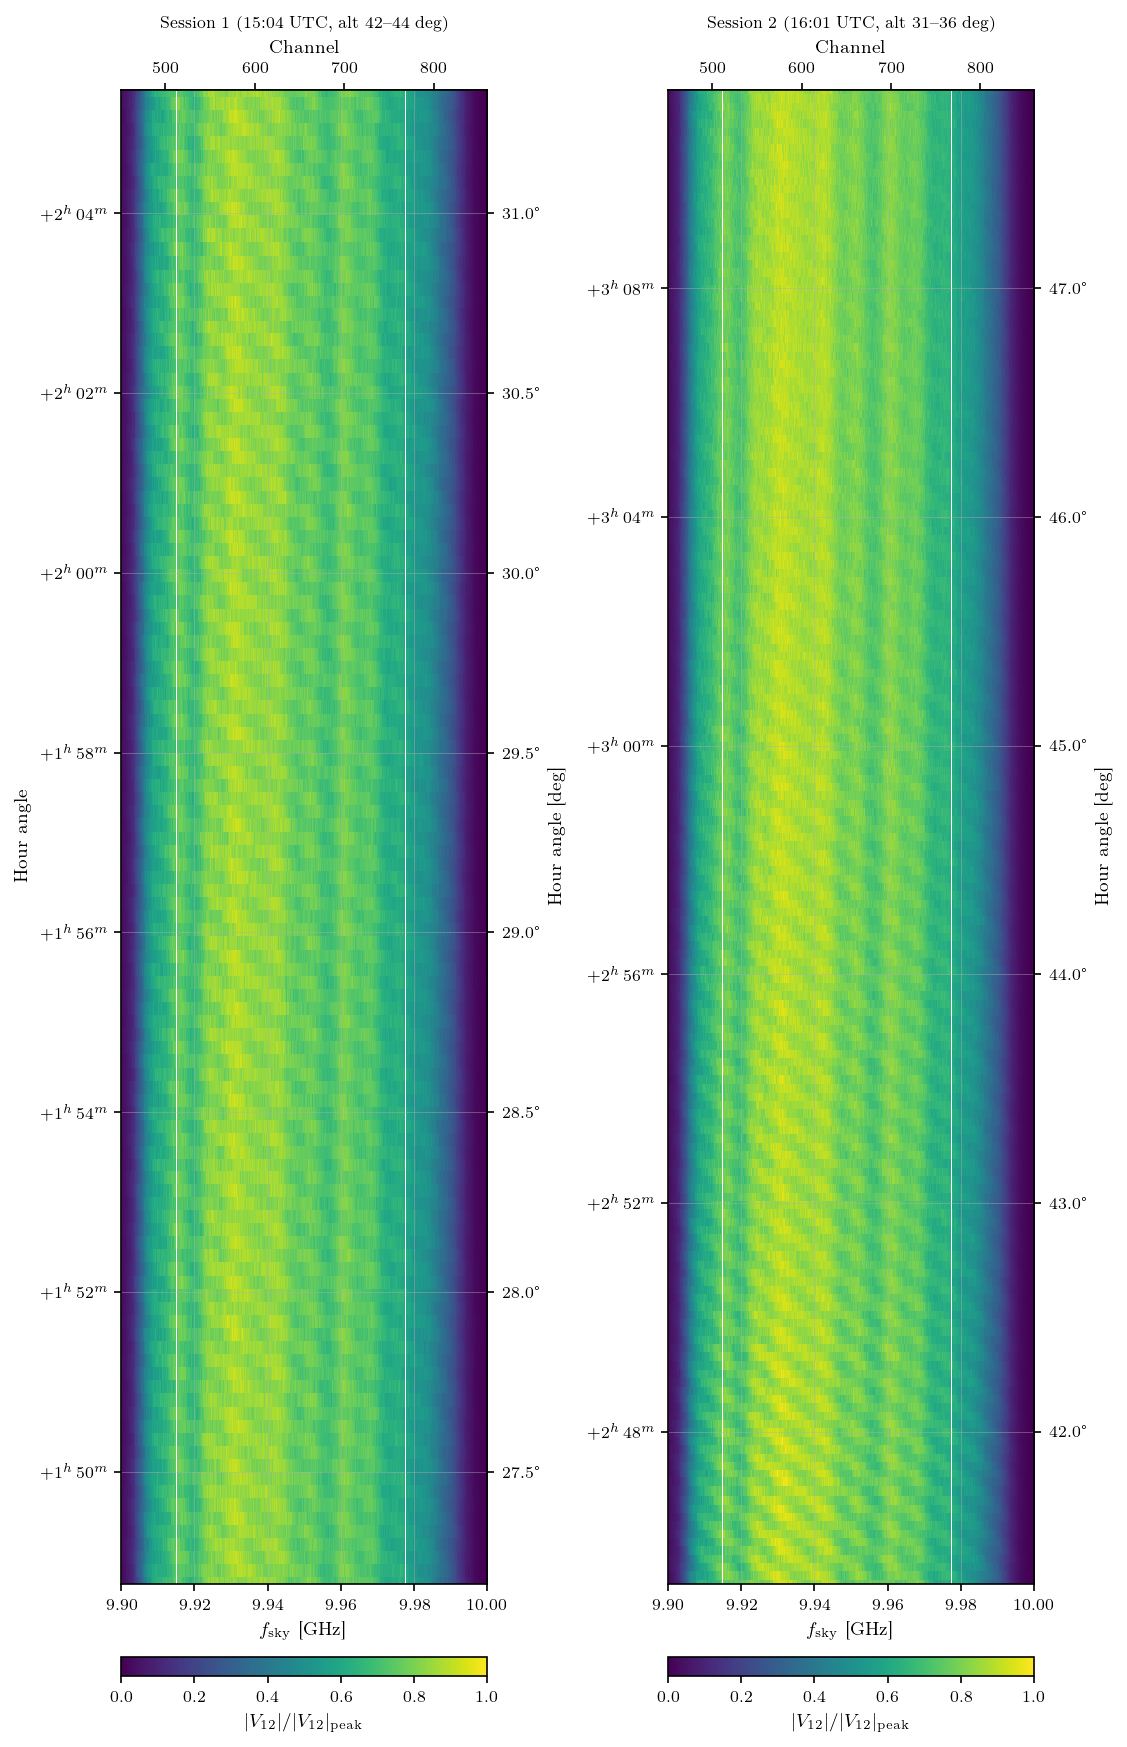

In [4]:
# ---------------------------------------------------------------------------
# Waterfall (spectrogram): amplitude vs frequency × hour angle
# Side-by-side: Session 1 (left) and Session 2 (right)
# Height scaled: 1 inch per 10 minutes of hour angle (largest session sets height)
# ---------------------------------------------------------------------------

ha_spans_min = [(sd['ha_deg'].max() - sd['ha_deg'].min()) / 2.5 * 60
                for sd in sessions_data]
fig_height = max(ha_spans_min) / 12

fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, fig_height),
                          sharey=False, sharex=True)

for ax, sd, label in zip(axes, sessions_data, SESSION_LABELS):
    amp_matrix = np.array([np.abs(f['corr']) / AMP_PEAK
                            for f in sd['files_s']]).astype(float)
    amp_matrix[:, BAD_CHANNELS] = np.nan

    im = ax.pcolormesh(
        F_SKY_GHZ,
        sd['ha_deg'],
        amp_matrix,
        vmin=0, vmax=1,
        cmap='viridis',
        shading='auto',
    )
    ax.set_xlim(*PLOT_BAND_GHZ)
    ax.set_ylim(sd['ha_deg'].min(), sd['ha_deg'].max())
    ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
    ax.set_title(label, fontsize=TICK_SIZE)
    ax.yaxis.set_major_formatter(HA_FMT)
    ax2 = ax.secondary_yaxis('right', functions=(lambda x: x, lambda x: x))
    ax2.set_ylabel('Hour angle [deg]')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:.1f}°'))
    ax_top = ax.secondary_xaxis('top', functions=(
        lambda ghz: (ghz * 1e9 - F_RF0_HZ) / DF_HZ,
        lambda k: (k * DF_HZ + F_RF0_HZ) / 1e9,
    ))
    ax_top.set_xlabel('Channel')
    fig.colorbar(im, ax=ax, location='bottom', shrink=1.0, pad=0.04,
                 label=r'$|V_{12}| / |V_{12}|_{\rm peak}$')

axes[0].set_ylabel('Hour angle')

fig.tight_layout()
plt.show()


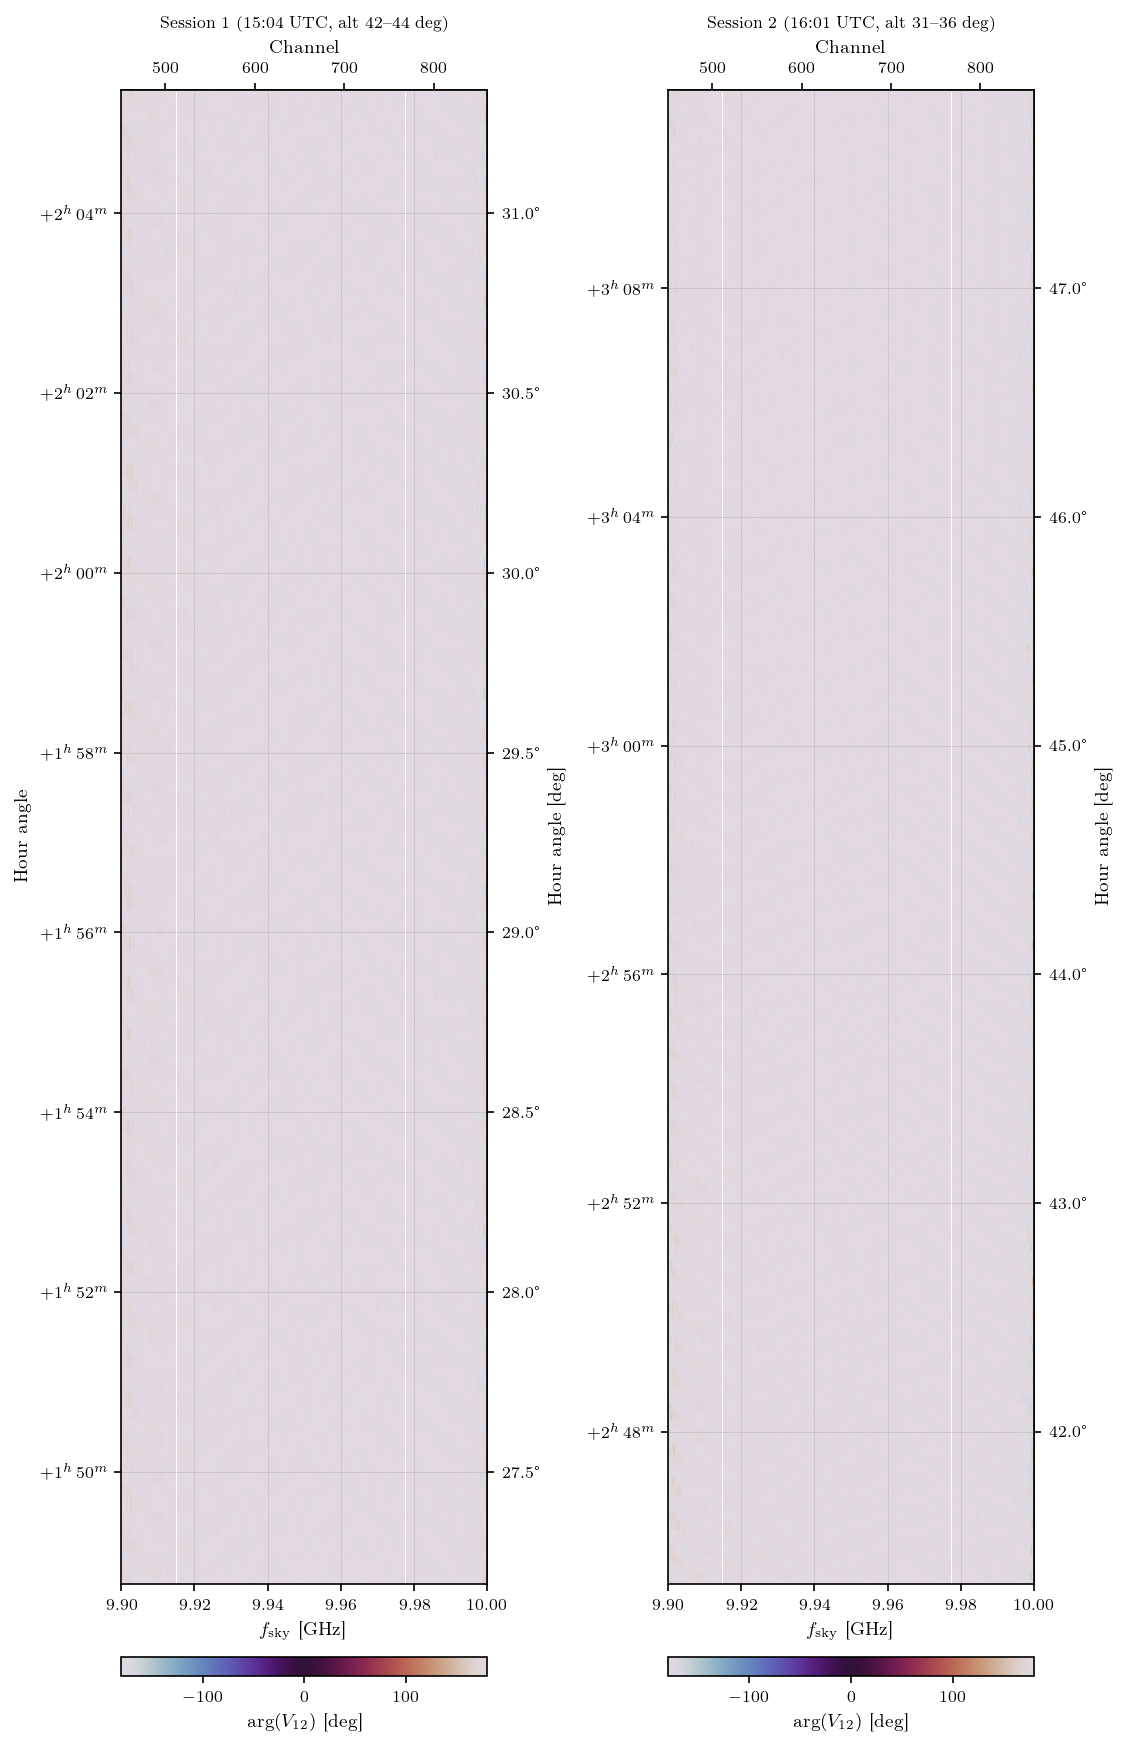

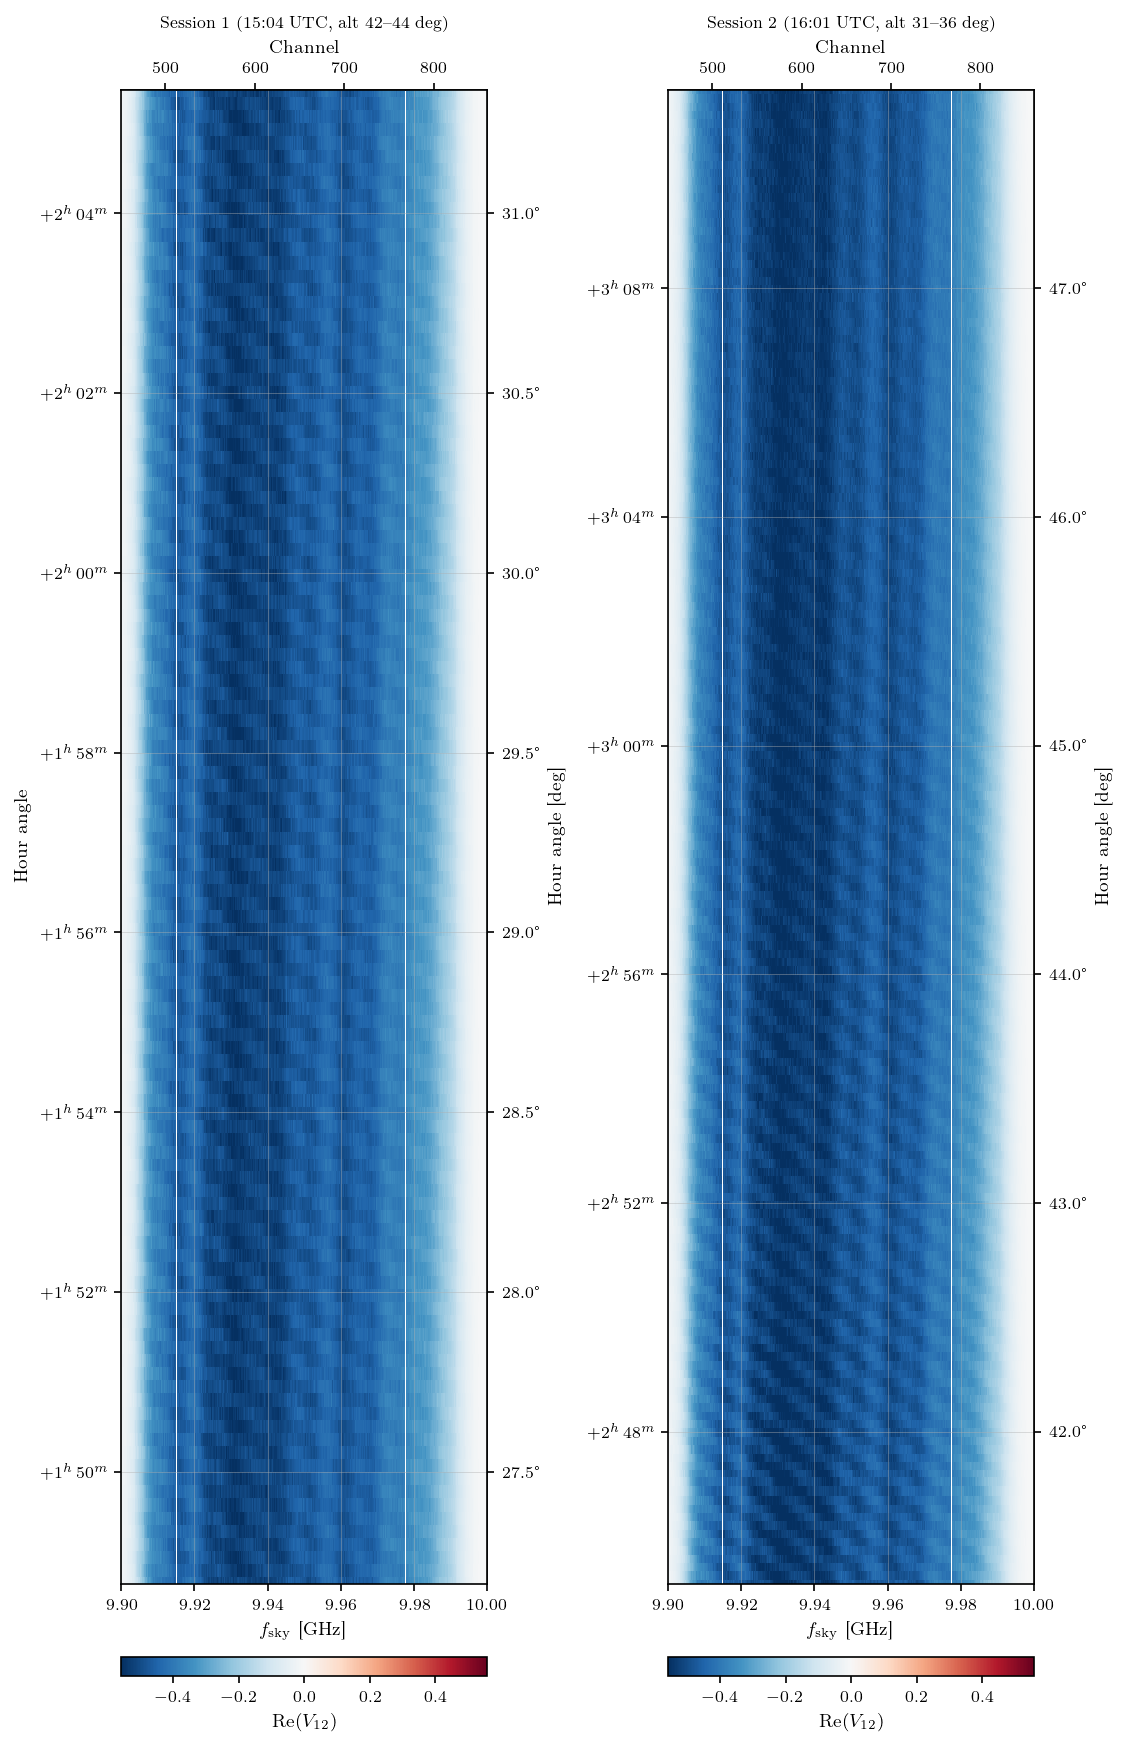

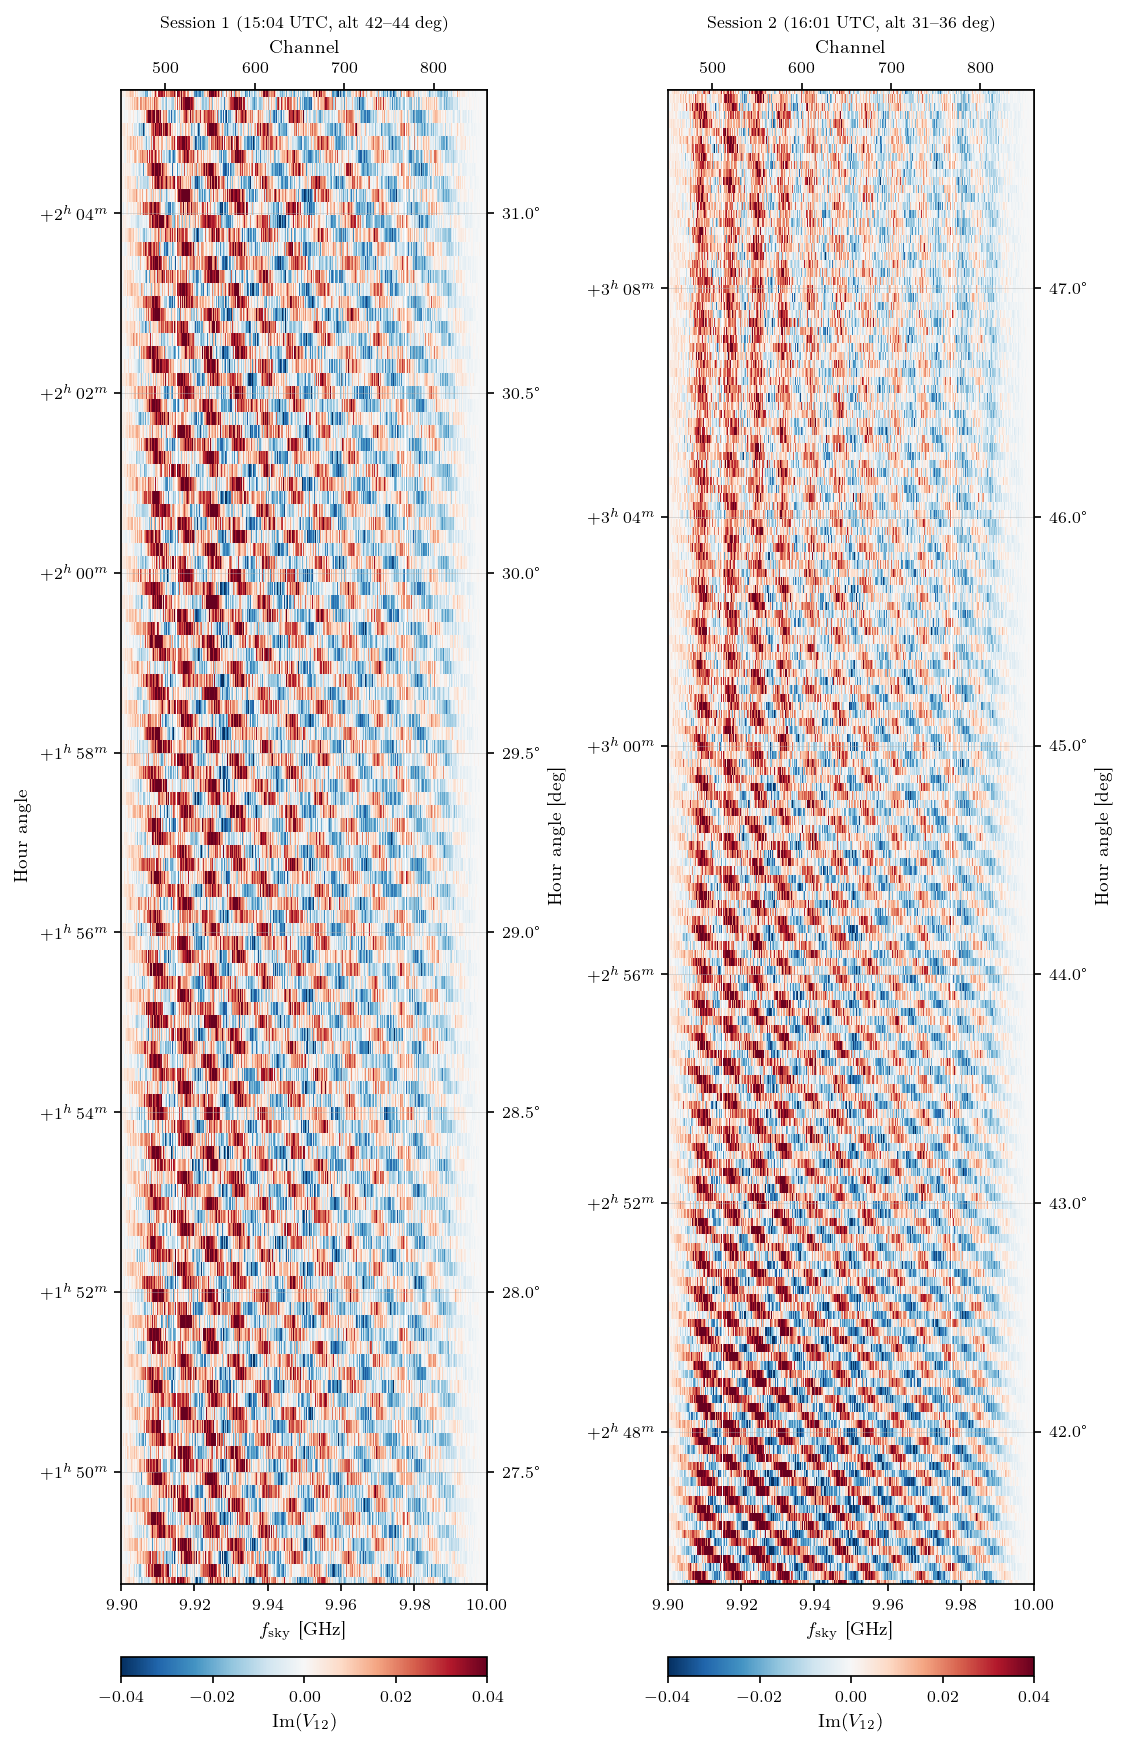

In [5]:
# ---------------------------------------------------------------------------
# Waterfalls: arg(V_12),  Re(V_12),  Im(V_12)  vs frequency × hour angle
# Same layout as the amplitude waterfall: Session 1 (left), Session 2 (right)
# ---------------------------------------------------------------------------

_wf_configs = [
    ('arg',  r'$\arg(V_{12})$ [deg]',  'twilight', -180, 180),
    ('re',   r'$\mathrm{Re}(V_{12})$', 'RdBu_r',   None, None),
    ('im',   r'$\mathrm{Im}(V_{12})$', 'RdBu_r',   None, None),
]

for kind, cbar_label, cmap, vmin_fixed, vmax_fixed in _wf_configs:

    # Build matrices for both sessions
    matrices = []
    for sd in sessions_data:
        rows = []
        for f in sd['files_s']:
            c = f['corr'].astype(complex)
            if kind == 'arg':
                row = np.rad2deg(np.angle(c))
            elif kind == 're':
                row = c.real
            else:
                row = c.imag
            row = row.copy()
            row[BAD_CHANNELS] = np.nan
            rows.append(row)
        matrices.append(np.array(rows))

    # Symmetric colour limits centred on zero for Re/Im
    if vmin_fixed is None:
        vabs = max(np.nanpercentile(np.abs(m), 99) for m in matrices)
        vmin, vmax = -vabs, vabs
    else:
        vmin, vmax = vmin_fixed, vmax_fixed

    ha_spans_min = [(sd['ha_deg'].max() - sd['ha_deg'].min()) / 2.5 * 60
                    for sd in sessions_data]
    fig_height = max(ha_spans_min) / 12

    fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, fig_height),
                              sharey=False, sharex=True)

    for ax, sd, label, mat in zip(axes, sessions_data, SESSION_LABELS, matrices):
        im = ax.pcolormesh(
            F_SKY_GHZ, sd['ha_deg'], mat,
            vmin=vmin, vmax=vmax,
            cmap=cmap, shading='auto',
        )
        ax.set_xlim(*PLOT_BAND_GHZ)
        ax.set_ylim(sd['ha_deg'].min(), sd['ha_deg'].max())
        ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
        ax.set_title(label, fontsize=TICK_SIZE)
        ax.yaxis.set_major_formatter(HA_FMT)
        ax2 = ax.secondary_yaxis('right', functions=(lambda x: x, lambda x: x))
        ax2.set_ylabel('Hour angle [deg]')
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:.1f}°'))
        ax_top = ax.secondary_xaxis('top', functions=(
            lambda ghz: (ghz * 1e9 - F_RF0_HZ) / DF_HZ,
            lambda k: (k * DF_HZ + F_RF0_HZ) / 1e9,
        ))
        ax_top.set_xlabel('Channel')
        fig.colorbar(im, ax=ax, location='bottom', shrink=1.0, pad=0.04,
                     label=cbar_label)

    axes[0].set_ylabel('Hour angle')
    fig.tight_layout()
    plt.show()


Session 1 (Session 1  (15:04 UTC,  alt 42--44 deg)):
  Captures   : 115
  Wall-clock : 1002.5 s  (16.7 min)
  On-sky     : 680.4 s  (11.3 min)
  Duty cycle : 67.9%
  n_acc      : min=5  mean=6.0  max=6
  Gap (s)    : min=2.69  median=2.79  mean=2.83  max=4.74



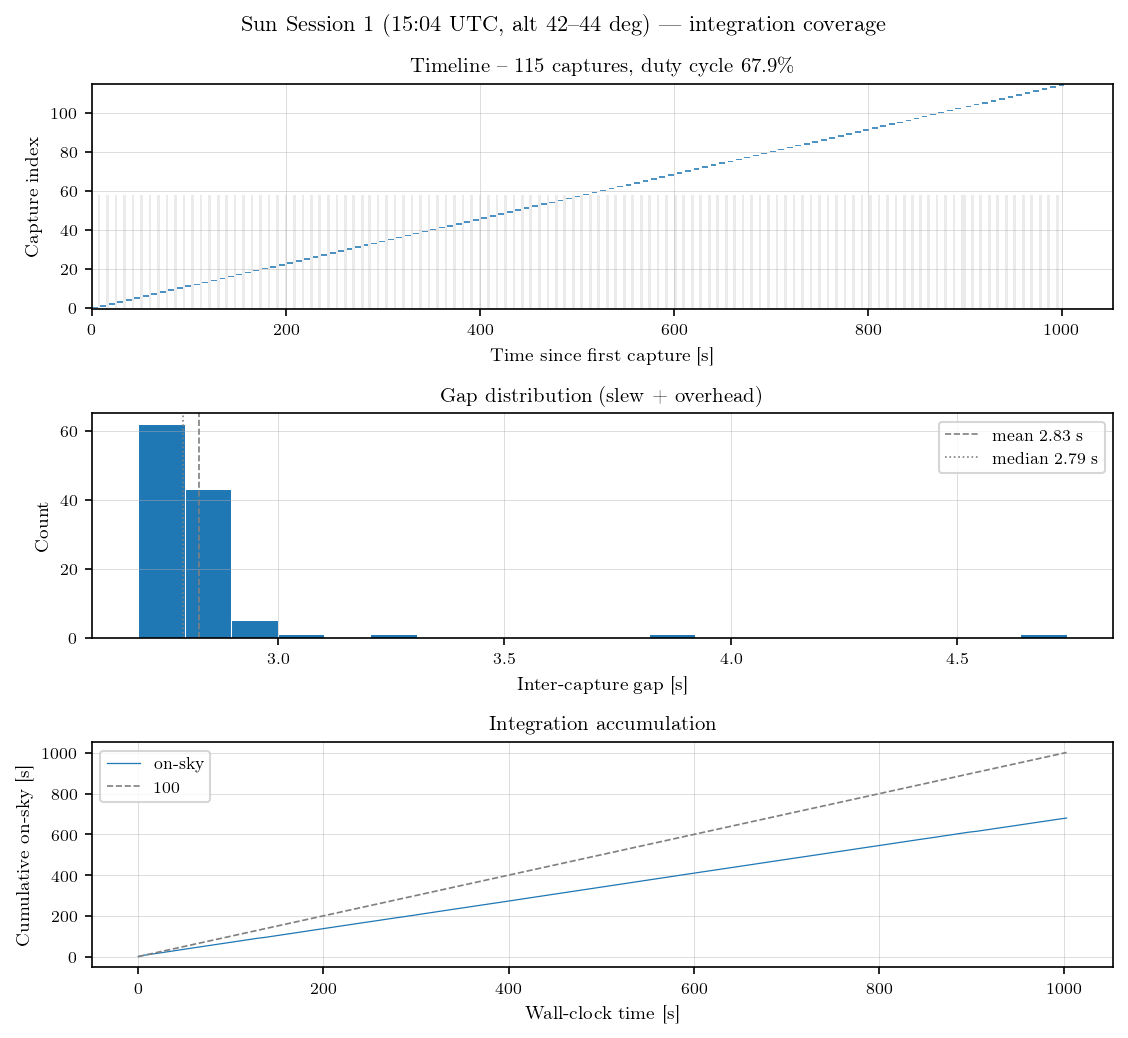

Session 2 (Session 2  (16:01 UTC,  alt 31--36 deg)):
  Captures   : 180
  Wall-clock : 1573.1 s  (26.2 min)
  On-sky     : 1063.6 s  (17.7 min)
  Duty cycle : 67.6%
  n_acc      : min=5  mean=6.0  max=6
  Gap (s)    : min=2.68  median=2.79  mean=2.85  max=4.98



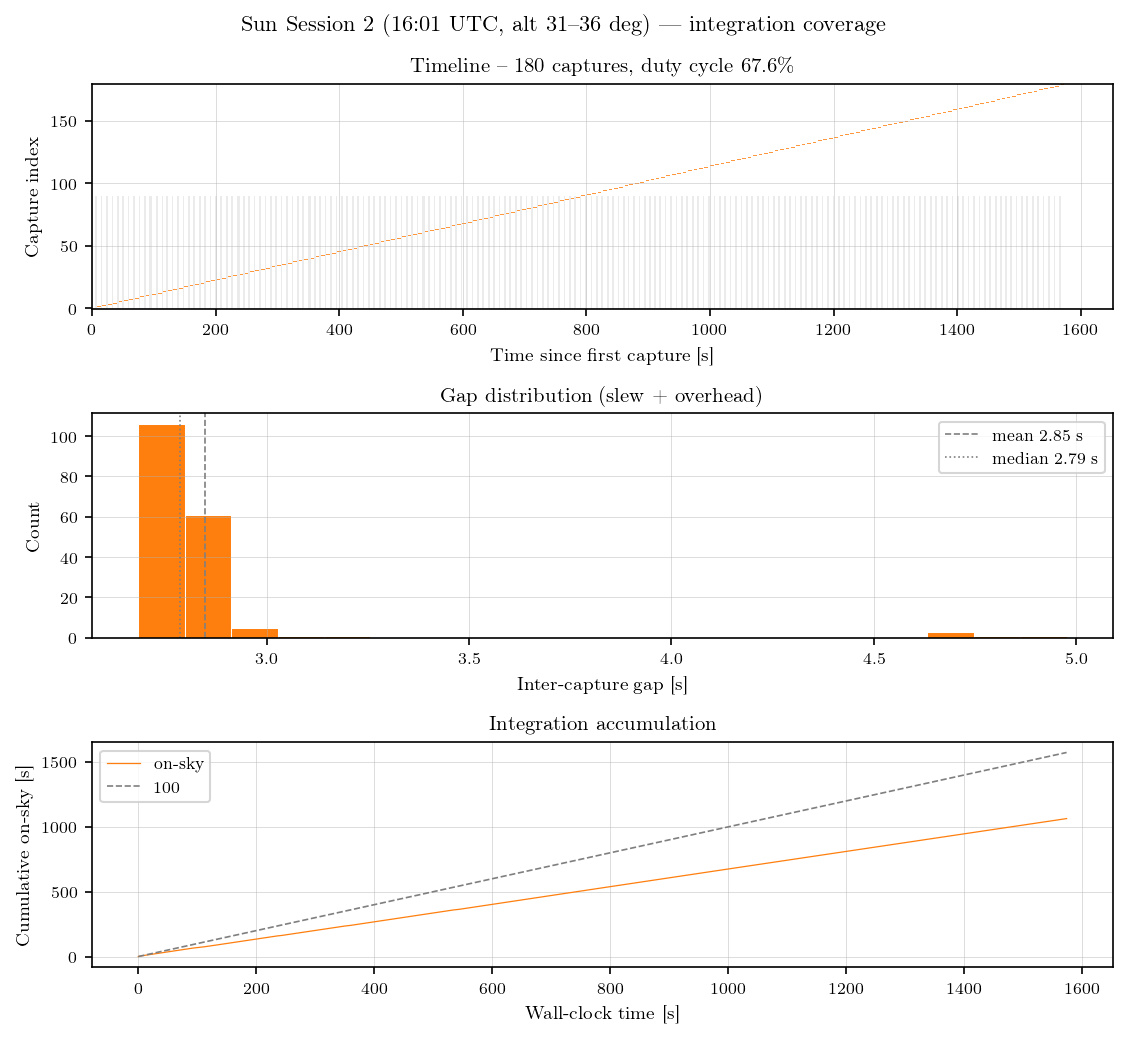

In [6]:
# ---------------------------------------------------------------------------
# Integration time coverage — one panel set per session
# ---------------------------------------------------------------------------

for s_idx, (sd, label, color) in enumerate(
        zip(sessions_data, SESSION_LABELS, SESSION_COLORS)):
    fs      = sd['files_s']
    t_start = np.array([float(f['unix_time_start']) for f in fs])
    t_end   = np.array([float(f['unix_time_end'])   for f in fs])
    n_acc   = np.array([int(f['n_acc'])             for f in fs])
    durs    = t_end - t_start
    gaps    = t_start[1:] - t_end[:-1]
    t0      = t_start[0]

    total_wall = t_end[-1] - t_start[0]
    total_sky  = durs.sum()
    duty       = total_sky / total_wall * 100

    print(f'Session {s_idx+1} ({label}):')
    print(f'  Captures   : {len(fs)}')
    print(f'  Wall-clock : {total_wall:.1f} s  ({total_wall/60:.1f} min)')
    print(f'  On-sky     : {total_sky:.1f} s  ({total_sky/60:.1f} min)')
    print(f'  Duty cycle : {duty:.1f}%')
    print(f'  n_acc      : min={n_acc.min()}  mean={n_acc.mean():.1f}  max={n_acc.max()}')
    print(f'  Gap (s)    : min={gaps.min():.2f}  median={np.median(gaps):.2f}  '
          f'mean={gaps.mean():.2f}  max={gaps.max():.2f}')
    print()

    fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 7))

    # Gantt timeline
    ax = axes[0]
    for i, (ts, te) in enumerate(zip(t_start - t0, t_end - t0)):
        ax.barh(i, te - ts, left=ts, height=0.8, color=color, alpha=0.8)
    for ts, te in zip(t_end[:-1] - t0, t_start[1:] - t0):
        ax.barh(0, te - ts, left=ts, height=len(fs),
                color=NEUTRAL_COLOR, alpha=0.15, zorder=0)
    ax.set_xlabel('Time since first capture [s]')
    ax.set_ylabel('Capture index')
    ax.set_title(rf'Timeline -- {len(fs)} captures, duty cycle {duty:.1f}\%')
    ax.set_ylim(-0.5, len(fs) - 0.5)

    # Gap histogram
    ax = axes[1]
    ax.hist(gaps, bins=20, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(gaps.mean(),     color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--',
               label=rf'mean {gaps.mean():.2f} s')
    ax.axvline(np.median(gaps), color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=':',
               label=rf'median {np.median(gaps):.2f} s')
    ax.set_xlabel('Inter-capture gap [s]')
    ax.set_ylabel('Count')
    ax.set_title('Gap distribution (slew + overhead)')
    ax.legend(fontsize=TICK_SIZE)

    # Cumulative integration
    ax = axes[2]
    t_wall_arr = np.concatenate([[0], t_end - t0])
    t_sky_arr  = np.concatenate([[0], np.cumsum(durs)])
    ax.plot(t_wall_arr, t_sky_arr, color=color, lw=LW_FINE, label='on-sky')
    ax.plot([0, t_wall_arr[-1]], [0, t_wall_arr[-1]],
            color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--', label='100 % duty')
    ax.set_xlabel('Wall-clock time [s]')
    ax.set_ylabel('Cumulative on-sky [s]')
    ax.set_title('Integration accumulation')
    ax.legend(fontsize=TICK_SIZE)

    fig.suptitle(rf'Sun {label} --- integration coverage')
    fig.tight_layout()
    plt.show()

/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_93376/3160456519.py:10: RuntimeWarning: Mean of empty slice
  re_mean_s = np.nanmean(corr_s.real, axis=0)


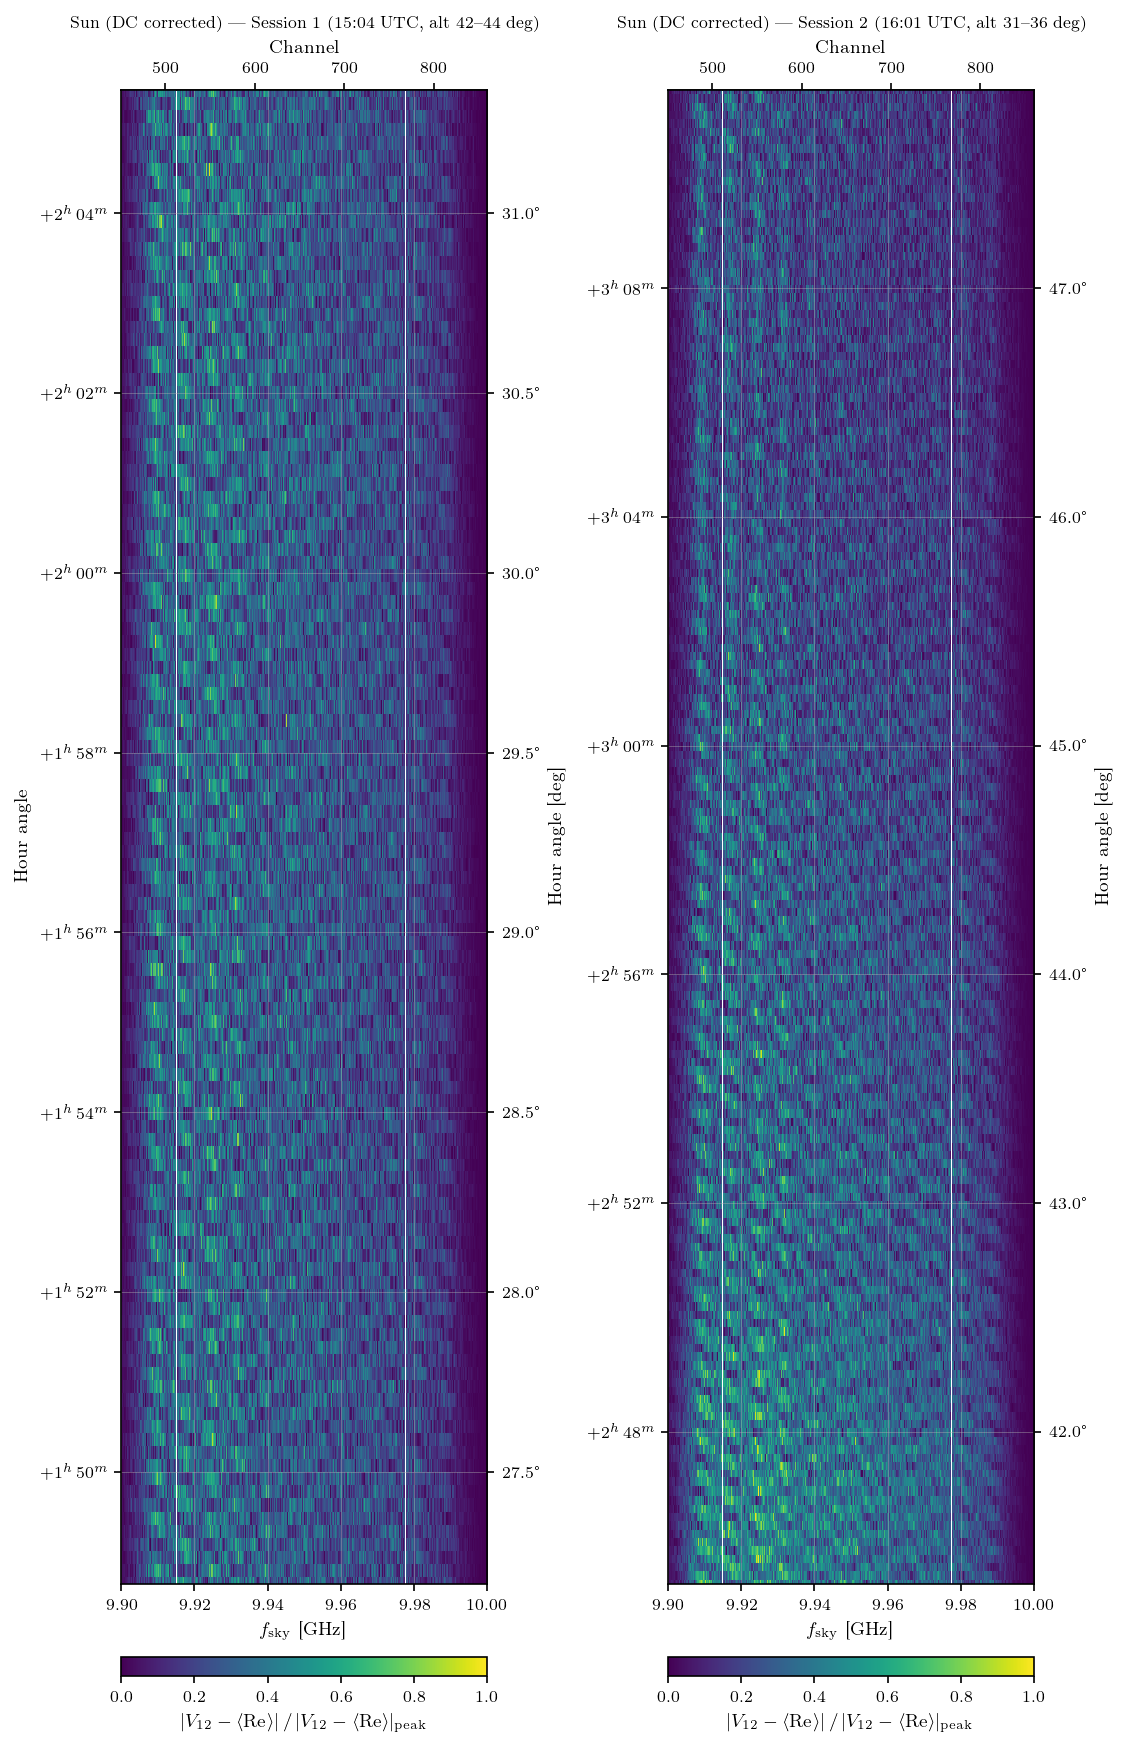

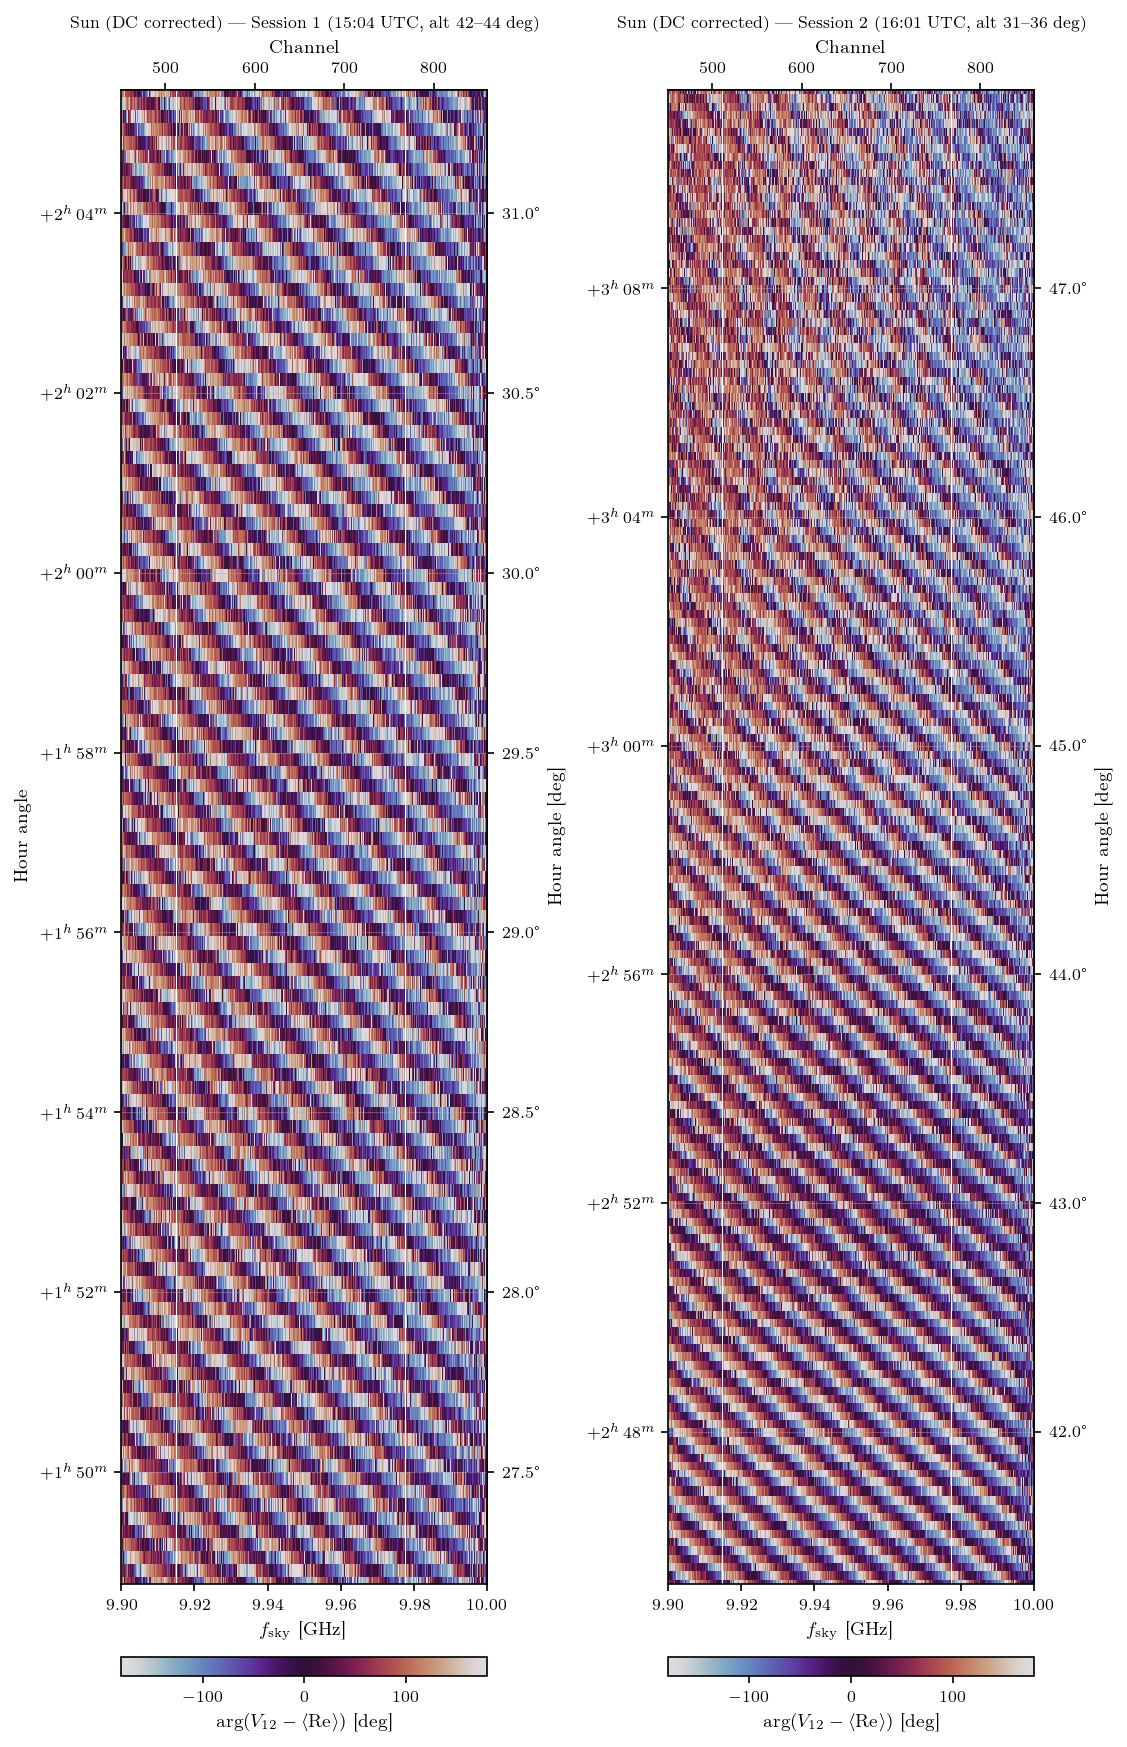

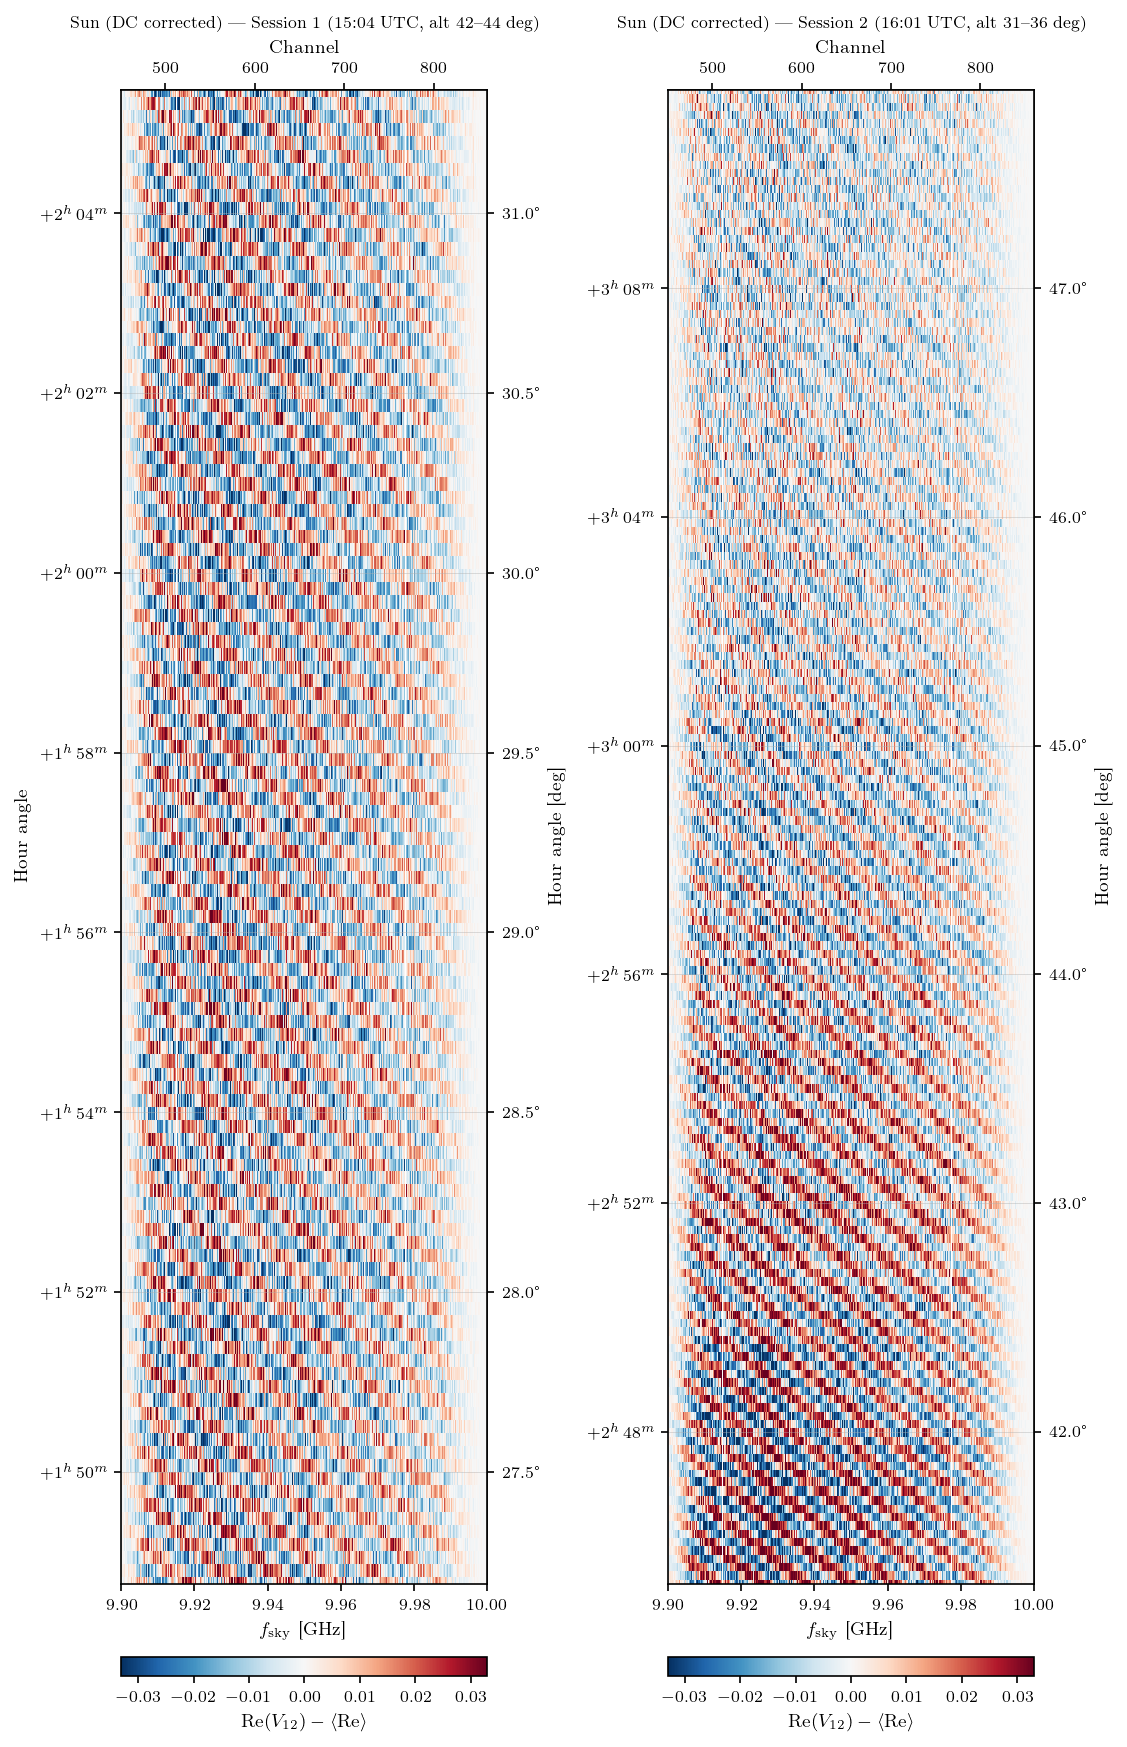

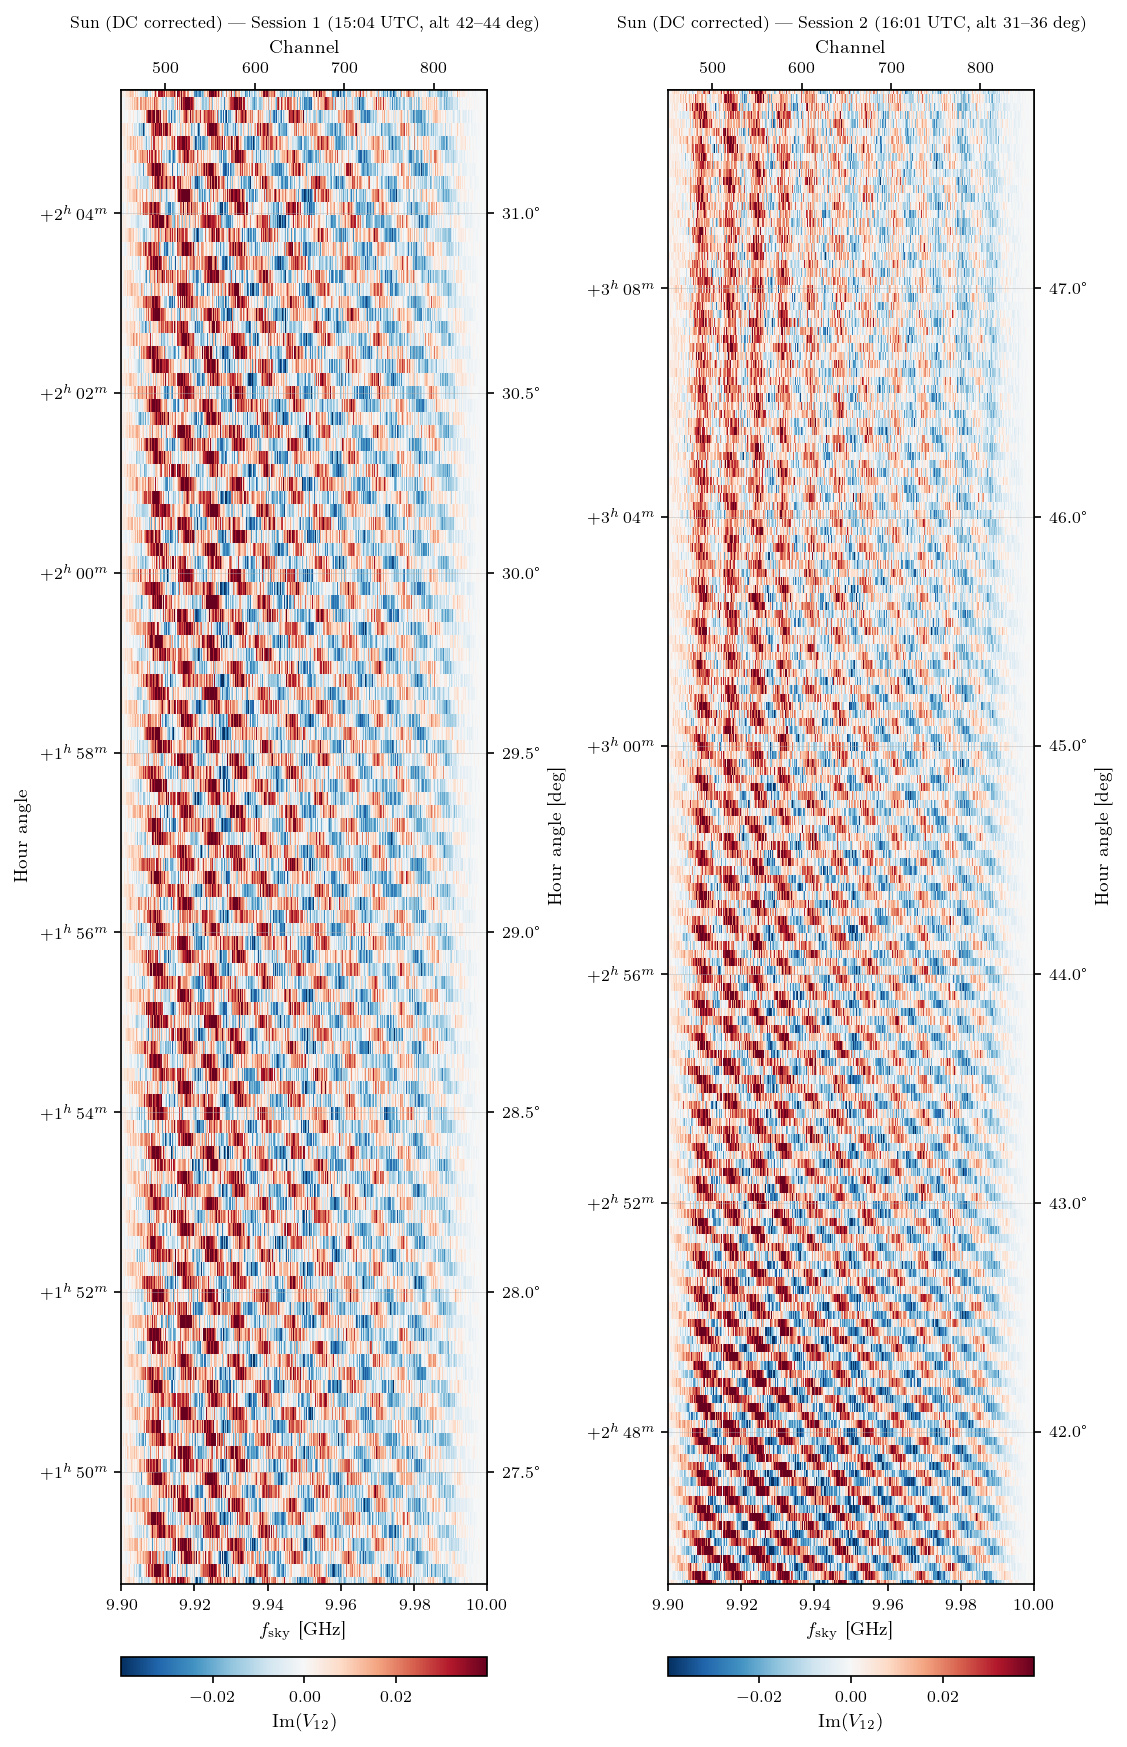

In [7]:
# ---------------------------------------------------------------------------
# DC offset correction: per-session mean-Re subtraction,
# then replot amp, arg, Re, Im waterfalls — Session 1 (left), Session 2 (right)
# ---------------------------------------------------------------------------

# Compute per-session DC and store in sessions_data
for sd in sessions_data:
    corr_s = np.array([f['corr'].astype(complex) for f in sd['files_s']])
    corr_s[:, BAD_CHANNELS] = np.nan
    re_mean_s = np.nanmean(corr_s.real, axis=0)
    sd['corr_dc'] = corr_s - re_mean_s[np.newaxis, :]

# Global amp_dc peak across both sessions for consistent normalisation
amp_dc_peak = max(np.nanmax(np.abs(sd['corr_dc'])) for sd in sessions_data)

_wf_configs_dc = [
    ('amp', r'$|V_{12} - \langle\mathrm{Re}\rangle|\,/\,|V_{12} - \langle\mathrm{Re}\rangle|_{\rm peak}$',
            'viridis', 0, 1),
    ('arg',  r'$\arg(V_{12} - \langle\mathrm{Re}\rangle)$ [deg]', 'twilight', -180, 180),
    ('re',   r'$\mathrm{Re}(V_{12}) - \langle\mathrm{Re}\rangle$', 'RdBu_r',  None, None),
    ('im',   r'$\mathrm{Im}(V_{12})$',                             'RdBu_r',  None, None),
]

for kind, cbar_label, cmap, vmin_fixed, vmax_fixed in _wf_configs_dc:
    matrices = []
    for sd in sessions_data:
        corr_dc = sd['corr_dc']
        if kind == 'amp':
            matrices.append(np.abs(corr_dc) / amp_dc_peak)
        elif kind == 'arg':
            matrices.append(np.rad2deg(np.angle(corr_dc)))
        elif kind == 're':
            matrices.append(corr_dc.real)
        else:
            matrices.append(corr_dc.imag)

    if vmin_fixed is None:
        vabs = max(np.nanpercentile(np.abs(m), 99) for m in matrices)
        vmin, vmax = -vabs, vabs
    else:
        vmin, vmax = vmin_fixed, vmax_fixed

    ha_spans_min = [(sd['ha_deg'].max() - sd['ha_deg'].min()) / 2.5 * 60
                    for sd in sessions_data]
    fig_height = max(ha_spans_min) / 12

    fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, fig_height),
                              sharey=False, sharex=True)

    for ax, sd, label, mat in zip(axes, sessions_data, SESSION_LABELS, matrices):
        im = ax.pcolormesh(
            F_SKY_GHZ, sd['ha_deg'], mat,
            vmin=vmin, vmax=vmax, cmap=cmap, shading='auto',
        )
        ax.set_xlim(*PLOT_BAND_GHZ)
        ax.set_ylim(sd['ha_deg'].min(), sd['ha_deg'].max())
        ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
        ax.set_title(rf'Sun (DC corrected) --- {label}', fontsize=TICK_SIZE)
        ax.yaxis.set_major_formatter(HA_FMT)
        ax2 = ax.secondary_yaxis('right', functions=(lambda x: x, lambda x: x))
        ax2.set_ylabel('Hour angle [deg]')
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:.1f}°'))
        ax_top = ax.secondary_xaxis('top', functions=(
            lambda ghz: (ghz * 1e9 - F_RF0_HZ) / DF_HZ,
            lambda k: (k * DF_HZ + F_RF0_HZ) / 1e9,
        ))
        ax_top.set_xlabel('Channel')
        fig.colorbar(im, ax=ax, location='bottom', shrink=1.0, pad=0.04,
                     label=cbar_label)

    axes[0].set_ylabel('Hour angle')
    fig.tight_layout()
    plt.show()
